## Email Spam Detection System

Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [10]:
import pandas as pd

df = pd.read_csv("data/spam.csv", encoding="latin-1")

print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


Load Dataset

In [11]:
df = pd.read_csv("data/spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Check dataset

In [12]:
print(df.shape)

df.info()

df.isnull().sum()

(5572, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


label      0
message    0
dtype: int64

Visualize Spam VS Ham

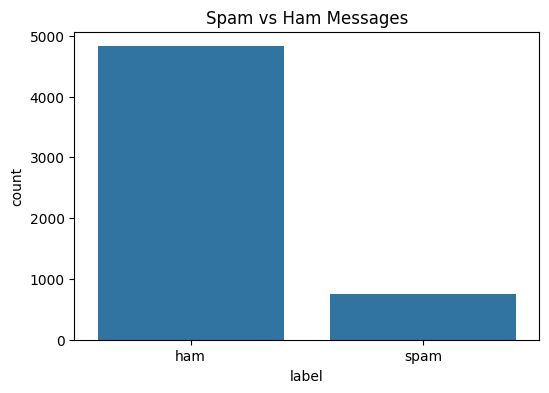

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Messages")
plt.savefig("screenshots/spam_ham_count.png")
plt.show()

Convert Labels

In [14]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Split Data

In [19]:
X = df['message']
y = df['label']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [23]:
X = df['message']
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Text Vectorization

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Train Model

In [30]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print ("model trained successfully")

model trained successfully


Prediction

In [31]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

[0 0 0 0 1 0 0 0 0 0]


Accuracy

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9623318385650225


Classification Report

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



Confusion Matrix

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[965   0]
 [ 42 108]]


Confusion Matrix Chart

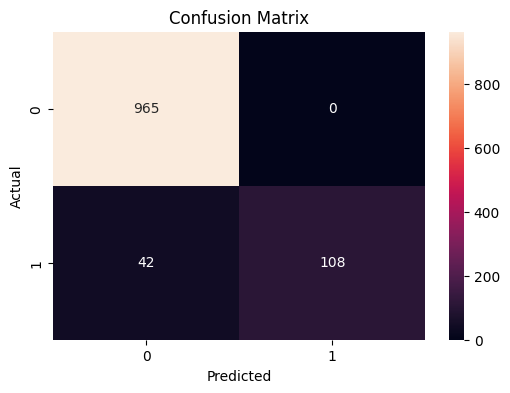

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.show()

Test Custom Email

In [41]:
sample_email = [
    "Congratulations! You have won a free iPhone. Click here now."
]

sample_vector = vectorizer.transform(sample_email)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam Email")

Not Spam Email
